In [1]:
import sys
import os
import pandas as pd
import numpy as np

# Add the project root directory to the Python path
# Assuming the notebook is in a directory at the same level as src
project_root = os.path.abspath('..')  # Adjust this path as needed
if project_root not in sys.path:
    sys.path.append(project_root)

import matplotlib.pyplot as plt
plt.style.use('fig.style')


In [2]:
L = 3
alphabet = ['A', 'C', 'G', 'T']  
figsize = (8,4)
bg_df = pd.DataFrame(index=range(L), columns=alphabet, data={'A': .1, 'C': .4, 'G': .4, 'T': .1})
bg_df


,A,C,G,T
0,0.1,0.4,0.4,0.1
1,0.1,0.4,0.4,0.1
2,0.1,0.4,0.4,0.1


In [3]:
from src import get_pairwise_augseqs
augseqs = get_pairwise_augseqs(seq_length=L, alphabet=alphabet, wildcard_char='*')
print(len(augseqs))
augseqs

61


['***',
 'A**',
 'C**',
 'G**',
 'T**',
 '*A*',
 '*C*',
 '*G*',
 '*T*',
 '**A',
 '**C',
 '**G',
 '**T',
 'AA*',
 'AC*',
 'AG*',
 'AT*',
 'CA*',
 'CC*',
 'CG*',
 'CT*',
 'GA*',
 'GC*',
 'GG*',
 'GT*',
 'TA*',
 'TC*',
 'TG*',
 'TT*',
 'A*A',
 'A*C',
 'A*G',
 'A*T',
 'C*A',
 'C*C',
 'C*G',
 'C*T',
 'G*A',
 'G*C',
 'G*G',
 'G*T',
 'T*A',
 'T*C',
 'T*G',
 'T*T',
 '*AA',
 '*AC',
 '*AG',
 '*AT',
 '*CA',
 '*CC',
 '*CG',
 '*CT',
 '*GA',
 '*GC',
 '*GG',
 '*GT',
 '*TA',
 '*TC',
 '*TG',
 '*TT']

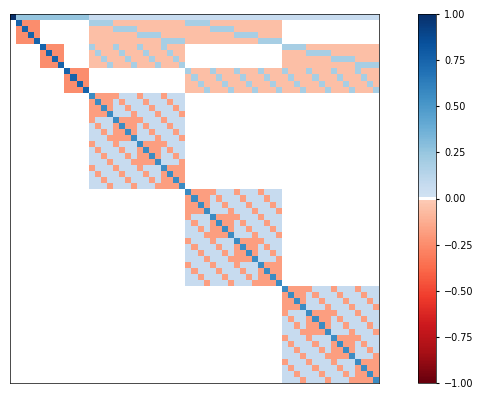

In [4]:
from src.get_hg_projection_matrix import get_hg_projection_matrix
from src.matrix_visualizer import visualize_matrix

# Test uniform backgroud
P_df = get_hg_projection_matrix(augseqs=augseqs, alphabet=alphabet, bg_type='uniform', wildcard_char='*', out_type='df')
visualize_matrix(P_df.values, show_grid=False, figsize=figsize)


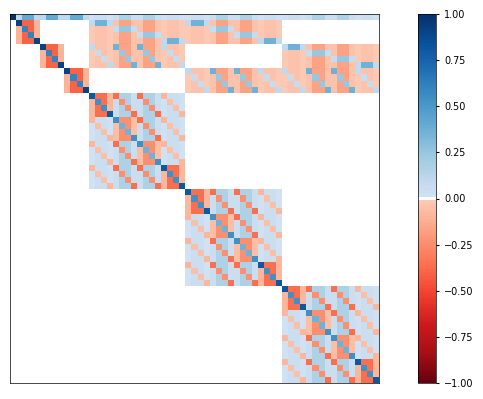

In [5]:
# Test uniform backgroud
P_df = get_hg_projection_matrix(augseqs=augseqs, alphabet=alphabet, bg_type='custom', bg_df=bg_df, wildcard_char='*', out_type='df')
visualize_matrix(P_df.values, show_grid=False, figsize=figsize)

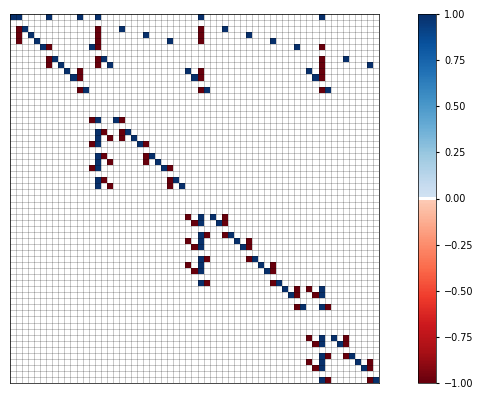

In [6]:
wt_seq = ('ACGT'*L)[:L]
P_df = get_hg_projection_matrix(augseqs=augseqs, alphabet=alphabet, bg_type='wildtype', wt_seq=wt_seq, wildcard_char='*', out_type='df')
visualize_matrix(P_df.values, show_grid=True, figsize=figsize)

In [7]:
import cProfile
import pstats

L = 20
alphabet = ['A', 'C', 'G', 'T']  
augseqs = get_pairwise_augseqs(seq_length=L, alphabet=alphabet, wildcard_char='*')
bg_df = pd.DataFrame(index=range(L), columns=alphabet, data={'A': .1, 'C': .4, 'G': .4, 'T': .1})
wt_seq = ('ACGT'*L)[:L]

# Default keyword arguments that are common across all background types
default_kwargs = {
    'augseqs': augseqs,
    'alphabet': alphabet, 
    'wildcard_char': '*',
    'out_type': 'sparse'
}

# Variable keyword arguments for different background types
bg_type_kwargs = {
    'wildtype': {'bg_type': 'wildtype', 'wt_seq': wt_seq},
    'uniform': {'bg_type': 'uniform'},
    'custom': {'bg_type': 'custom', 'bg_df': bg_df},
}

# Update each params dict with the default kwargs
for bg_type in bg_type_kwargs:
    bg_type_kwargs[bg_type].update(default_kwargs)

# Loop over background types
for bg_type, kwargs in bg_type_kwargs.items():
    print(f"\nProfiling with {bg_type} background:")
    with cProfile.Profile() as profiler:
        P_df = get_hg_projection_matrix(**kwargs)
        
    stats = pstats.Stats(profiler)
    stats.strip_dirs().sort_stats('cumulative').print_stats(10)



Profiling with wildtype background:
         89914 function calls (89900 primitive calls) in 0.203 seconds

   Ordered by: cumulative time
   List reduced from 174 to 10 due to restriction <10>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.130    0.130    0.151    0.151 get_hg_projection_matrix.py:8(get_hg_projection_matrix)
        5    0.033    0.007    0.038    0.008 socket.py:632(send)
     3121    0.013    0.000    0.026    0.000 get_suborbit_augseqs.py:8(get_suborbit_augseqs)
    76401    0.012    0.000    0.012    0.000 {method 'join' of 'str' objects}
        1    0.000    0.000    0.002    0.002 _compressed.py:29(__init__)
        1    0.000    0.000    0.002    0.002 _coo.py:30(__init__)
       10    0.001    0.000    0.001    0.000 {built-in method numpy.asarray}
     9451    0.001    0.000    0.001    0.000 {method 'append' of 'list' objects}
        3    0.001    0.000    0.001    0.000 {built-in method numpy.array}
        3    0